In [11]:
import pandas as pd
from pathlib import Path

combined_protein_path = Path(
    "/cmnfs/ENB/search_results/FinalFragger/Banana/FragPipeSearchResults/combined_protein.tsv"
)

In [12]:
# 1. Read FragPipe combined_protein.tsv and keep only "[experiment] Intensity" columns.
#    We keep the plain intensity columns and drop the "MaxLFQ Intensity" ones.
df = pd.read_csv(combined_protein_path, sep="\t", low_memory=False)

intensity_cols = [
    c for c in df.columns
    if c.endswith(" Intensity") and "MaxLFQ" not in c
]

# 2. Remove proteins starting with "rev_" (decoys).
is_decoy = df["Protein"].str.startswith("rev_")
df = df[~is_decoy]

# 3. Build the table: proteins in rows, intensities in columns.
intensities = df.set_index("Protein")[intensity_cols]
intensities

,P087149_1 Intensity,P087150_2 Intensity,P087151_3 Intensity,P087152_4 Intensity,P087153_5 Intensity,P087154_6 Intensity,P087155_7 Intensity,P087156_8 Intensity,P087157_9 Intensity,P087158_10 Intensity,...,P087162_14 Intensity,P087163_15 Intensity,P087164_16 Intensity,P087165_17 Intensity,P087166_18 Intensity,P087167_19 Intensity,P087168_20 Intensity,P087169_21 Intensity,P087170_22 Intensity,P087171_23 Intensity
Protein,,,,,,,,,,,,,,,,,,,,,
GWHCAXY00000001_000001.1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.186542e+07,1.810470e+07,6.018401e+07,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.595894e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
GWHCAXY00000001_000005.1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.455153e+06,0.000000e+00,1.150124e+08,0.000000e+00,0.000000e+00,4.619342e+07,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.422442e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
GWHCAXY00000001_000006.1,9.359279e+09,9.165518e+09,8.570905e+09,4.617056e+09,1.207226e+09,1.547116e+07,8.179268e+09,3.327421e+08,1.811683e+09,8.696217e+09,...,2.050613e+08,4.539743e+09,5.178288e+09,6.778105e+08,1.617919e+09,2.567658e+09,1.596208e+09,4.598060e+07,3.897402e+07,7.491779e+09
GWHCAXY00000001_000010.1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.816932e+07,9.602045e+08,0.000000e+00,0.000000e+00,1.658248e+08,0.000000e+00
GWHCAXY00000001_000013.1,6.302786e+09,6.345247e+09,8.056311e+09,1.147612e+10,6.481905e+09,6.194967e+09,1.208519e+10,5.159095e+09,6.206072e+09,5.083690e+09,...,3.243718e+09,3.018220e+10,3.042192e+10,1.582531e+09,6.635168e+09,7.076925e+09,1.198640e+09,9.343650e+07,4.584539e+08,4.278341e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sp|P62979|RS27A_HUMAN,1.602271e+09,1.073018e+09,5.250033e+08,8.980036e+08,5.191172e+08,1.728019e+08,9.588061e+08,1.139922e+09,1.311658e+09,8.083541e+08,...,0.000000e+00,1.169898e+09,5.599779e+08,3.785689e+08,3.923615e+08,1.945561e+09,2.039151e+09,1.931877e+07,9.461766e+08,9.215414e+08
sp|P68871|HBB_HUMAN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.975236e+06,1.114067e+08,0.000000e+00,2.795401e+06,3.616054e+07,0.000000e+00,5.775742e+07,9.967964e+06,0.000000e+00,0.000000e+00
sp|P69905|HBA_HUMAN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,1.636711e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.046412e+07,0.000000e+00,0.000000e+00,0.000000e+00


In [13]:
# 4. TIC / median-of-totals normalization.
#    - sum each column
#    - median of those column sums
#    - normalization factor per column = column_sum / median
#    - DIVIDE each value in a column by its factor, so every column total
#      is scaled to the median total (equal column sums after normalization).
column_sums = intensities.sum(axis=0)

median_sum = column_sums.median()

norm_factors = column_sums / median_sum

normalized = intensities.divide(norm_factors, axis=1)

# Inspect the factors and the result.
print("Column sums:")
print(column_sums)
print(f"\nMedian of column sums: {median_sum}")
print("\nNormalization factors:")
print(norm_factors)

normalized

Column sums:
P087149_1 Intensity     4.557412e+13
P087150_2 Intensity     4.437669e+13
P087151_3 Intensity     4.510718e+13
P087152_4 Intensity     4.059799e+13
P087153_5 Intensity     3.335524e+13
P087154_6 Intensity     9.096457e+12
P087155_7 Intensity     4.166236e+13
P087156_8 Intensity     3.644190e+13
P087157_9 Intensity     3.573015e+13
P087158_10 Intensity    4.490497e+13
P087159_11 Intensity    2.674219e+13
P087160_12 Intensity    3.044542e+13
P087161_13 Intensity    5.214078e+12
P087162_14 Intensity    1.112839e+13
P087163_15 Intensity    3.301249e+13
P087164_16 Intensity    2.708581e+13
P087165_17 Intensity    2.734011e+13
P087166_18 Intensity    3.957752e+13
P087167_19 Intensity    6.735253e+13
P087168_20 Intensity    2.172884e+13
P087169_21 Intensity    3.008599e+12
P087170_22 Intensity    1.580285e+13
P087171_23 Intensity    3.822772e+13
dtype: float64

Median of column sums: 33355239593543.65

Normalization factors:
P087149_1 Intensity     1.366326
P087150_2 Intensity   

,P087149_1 Intensity,P087150_2 Intensity,P087151_3 Intensity,P087152_4 Intensity,P087153_5 Intensity,P087154_6 Intensity,P087155_7 Intensity,P087156_8 Intensity,P087157_9 Intensity,P087158_10 Intensity,...,P087162_14 Intensity,P087163_15 Intensity,P087164_16 Intensity,P087165_17 Intensity,P087166_18 Intensity,P087167_19 Intensity,P087168_20 Intensity,P087169_21 Intensity,P087170_22 Intensity,P087171_23 Intensity
Protein,,,,,,,,,,,,,,,,,,,,,
GWHCAXY00000001_000001.1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.916639e+07,1.690131e+07,4.470445e+07,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.903405e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
GWHCAXY00000001_000005.1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.455153e+06,0.000000e+00,9.207993e+07,0.000000e+00,0.000000e+00,3.431229e+07,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.199675e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
GWHCAXY00000001_000006.1,6.849962e+09,6.889159e+09,6.337895e+09,3.793365e+09,1.207226e+09,5.673023e+07,6.548392e+09,3.045586e+08,1.691264e+09,6.459516e+09,...,6.146327e+08,4.586876e+09,6.376884e+09,8.269365e+08,1.363553e+09,1.271590e+09,2.450288e+09,5.097702e+08,8.226286e+07,6.536882e+09
GWHCAXY00000001_000010.1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.374061e+07,4.755256e+08,0.000000e+00,0.000000e+00,3.500081e+08,0.000000e+00
GWHCAXY00000001_000013.1,4.612945e+09,4.769333e+09,5.957371e+09,9.428761e+09,6.481905e+09,2.271594e+10,9.675508e+09,4.722116e+09,5.793567e+09,3.776145e+09,...,9.722433e+09,3.049556e+10,3.746354e+10,1.930706e+09,5.592003e+09,3.504731e+09,1.839994e+09,1.035897e+09,9.676631e+08,3.733026e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sp|P62979|RS27A_HUMAN,1.172686e+09,8.065222e+08,3.882223e+08,7.377982e+08,5.191172e+08,6.336368e+08,7.676284e+08,1.043370e+09,1.224475e+09,6.004423e+08,...,0.000000e+00,1.182045e+09,6.895935e+08,4.618584e+08,3.306753e+08,9.635074e+08,3.130235e+09,2.141801e+08,1.997104e+09,8.040824e+08
sp|P68871|HBB_HUMAN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.920396e+06,1.125634e+08,0.000000e+00,3.410421e+06,3.047547e+07,0.000000e+00,8.866156e+07,1.105112e+08,0.000000e+00,0.000000e+00
sp|P69905|HBA_HUMAN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,1.653704e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.388686e+08,0.000000e+00,0.000000e+00,0.000000e+00


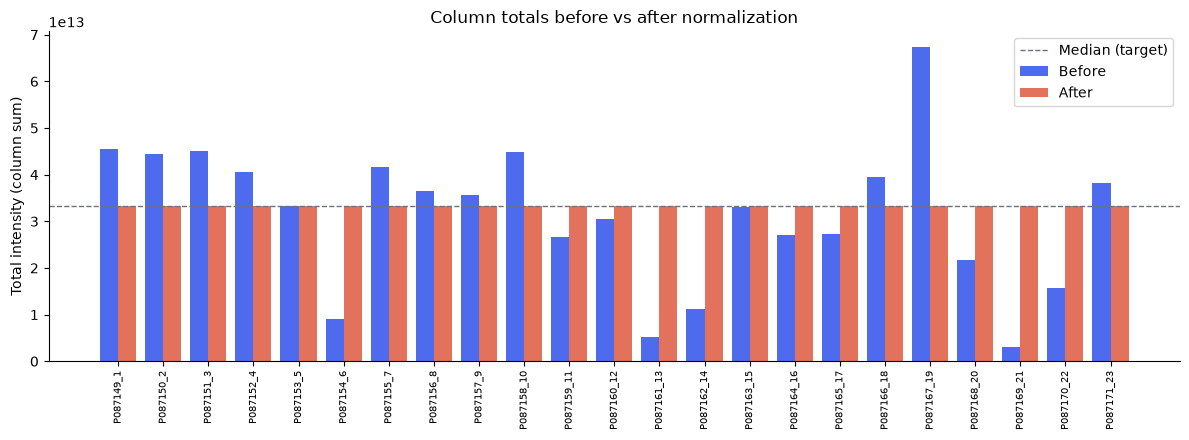

In [14]:
# Sanity check 1: column totals before vs after normalization.
# For median-of-totals normalization the "after" bars should be closer together.
import numpy as np
import matplotlib.pyplot as plt

samples = [c.replace(" Intensity", "") for c in intensities.columns]
sums_before = intensities.sum(axis=0).values
sums_after = normalized.sum(axis=0).values

x = np.arange(len(samples))
w = 0.4
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(x - w / 2, sums_before, w, label="Before", color="#4f6bed")
ax.bar(x + w / 2, sums_after, w, label="After", color="#e2725b")
ax.axhline(median_sum, color="#6b7280", lw=1, ls="--", label="Median (target)")
ax.set_xticks(x)
ax.set_xticklabels(samples, rotation=90, fontsize=7)
ax.set_ylabel("Total intensity (column sum)")
ax.set_title("Column totals before vs after normalization")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

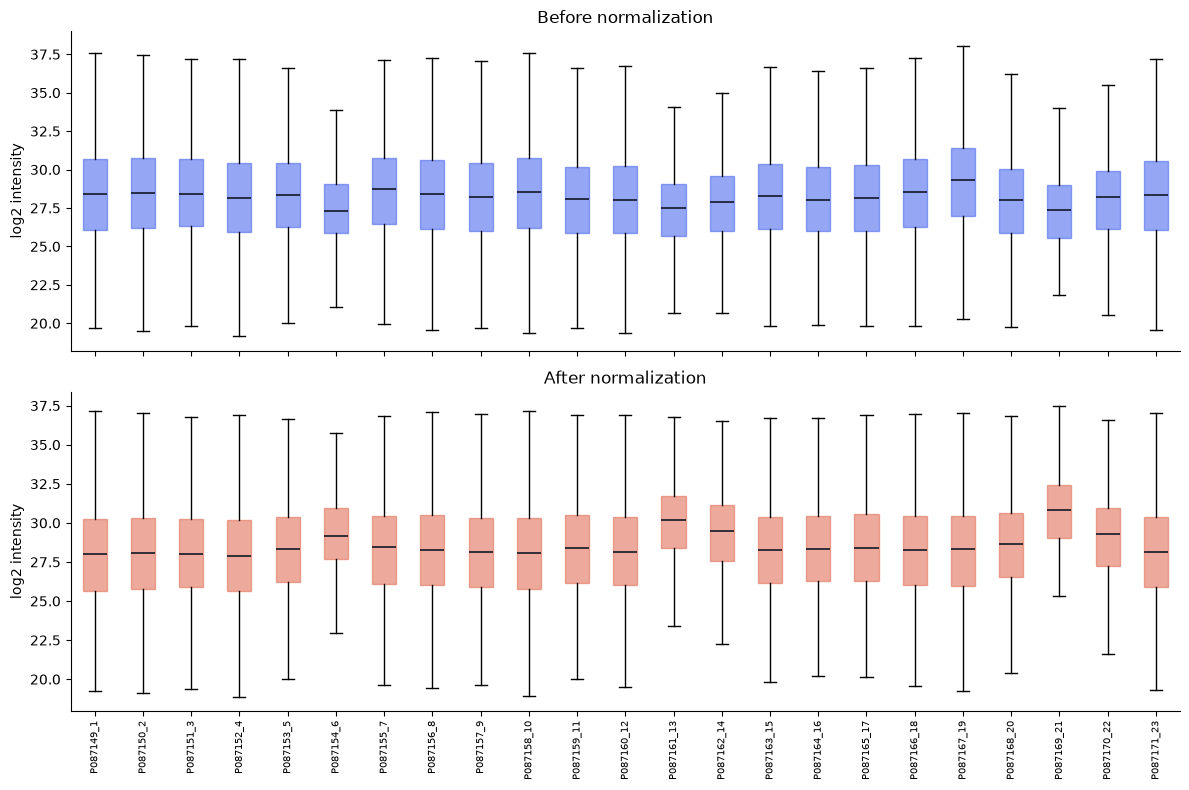

In [15]:
# Sanity check 2: per-sample log2 intensity distributions before vs after.
# Zeros are dropped (log undefined). Well-normalized samples have aligned medians.
def log2_nonzero(frame):
    return [np.log2(col[col > 0].values) for _, col in frame.items()]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, data, title, color in [
    (axes[0], log2_nonzero(intensities), "Before normalization", "#4f6bed"),
    (axes[1], log2_nonzero(normalized), "After normalization", "#e2725b"),
]:
    bp = ax.boxplot(data, showfliers=False, patch_artist=True,
                    medianprops=dict(color="#111827", lw=1.2))
    for box in bp["boxes"]:
        box.set(facecolor=color, alpha=0.6, edgecolor=color)
    ax.set_ylabel("log2 intensity")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)

axes[1].set_xticks(np.arange(1, len(samples) + 1))
axes[1].set_xticklabels(samples, rotation=90, fontsize=7)
fig.tight_layout()
plt.show()

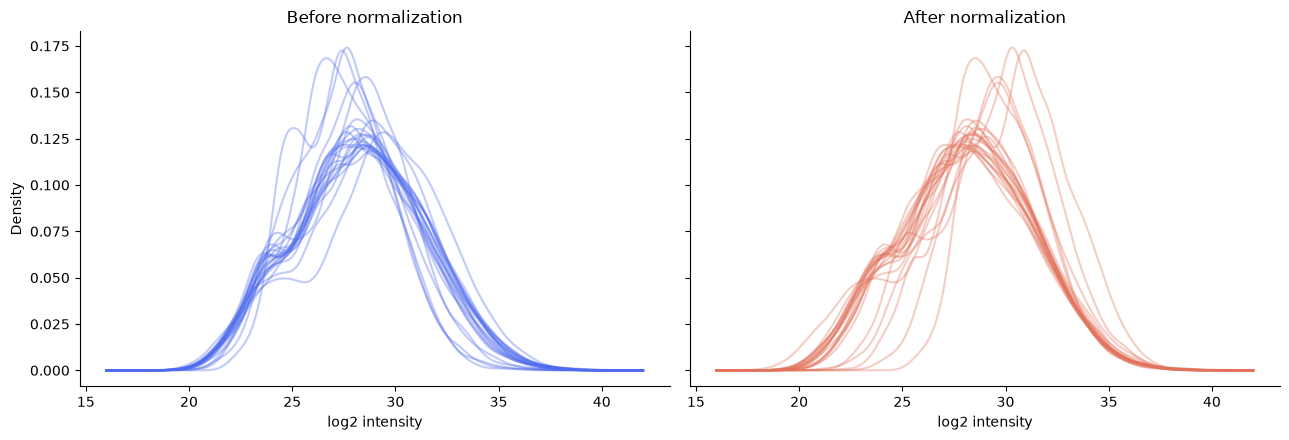

In [16]:
# Sanity check 3: per-sample log2 intensity density distributions, before vs after.
# One smooth KDE curve per sample. After normalization the curves should overlap
# more tightly. All curves share one hue: identity of the individual sample is not
# the point here, the alignment of the distributions is.
from scipy.stats import gaussian_kde

grid = np.linspace(16, 42, 400)

def kde_curves(frame):
    curves = []
    for _, col in frame.items():
        vals = np.log2(col[col > 0].values)
        curves.append(gaussian_kde(vals)(grid))
    return curves

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
for ax, frame, title, color in [
    (axes[0], intensities, "Before normalization", "#4f6bed"),
    (axes[1], normalized, "After normalization", "#e2725b"),
]:
    for dens in kde_curves(frame):
        ax.plot(grid, dens, color=color, alpha=0.35)
    ax.set_xlabel("log2 intensity")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Density")
fig.tight_layout()
plt.show()